# 1: Установка и импорт библиотек

In [23]:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify lightgbm xgboost catboost

In [24]:
# Раскомментируй установку при первом запуске в Colab:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify lightgbm xgboost catboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box, Point
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Импортируем бустинги для выполнения заданий 12-14
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

from sklearn.neighbors import BallTree

print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


# 1. Область исследования



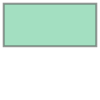

In [25]:
# Центральная часть Санкт-Петербурга
bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

polygon_wgs

# 2. Загрузка уличной сети из OSM

In [26]:
#Задание 1

# Загружаем граф дорожной сети через полигон
G = ox.graph_from_polygon(
    polygon_wgs,                 # Передаем наш полигон гео-границ
    network_type="drive",        # Указываем автомобильный тип сети
    simplify=True,
    retain_all=False
)

# Получаем GeoDataFrame узлов и рёбер
nodes, edges = ox.graph_to_gdfs(G)

print(f"Размерность таблицы ребер: {edges.shape}")
edges.head()

Размерность таблицы ребер: (16194, 15)


osmid       highway lanes  maxspeed  \
u      v          key                                                          
219808 2327840    0                   33997807  primary_link     2  RU:urban   
       389449562  0                  201380605       primary     3  RU:urban   
219811 1832085962 0                   33997784  primary_link     2  RU:urban   
       1465050831 0    [1123339577, 178581714]       primary     3  RU:urban   
219812 249890545  0                    4459876       primary     2  RU:urban   

                       oneway reversed      length                       name  \
u      v          key                                                           
219808 2327840    0     False    False   26.026139                        NaN   
       389449562  0      True    False   31.504625         Лиговский проспект   
219811 1832085962 0     False    False   27.905147                        NaN   
       1465050831 0      True    False  394.654005         Лиговский проспект   
219812 249890545  0      True    False   33.758153  Воздухоплавательная улица   

                                                                geometry  \
u      v          key                                                      
219808 2327840    0    LINESTRING (30.33142 59.89509, 30.33109 59.89526)   
       389449562  0    LINESTRING (30.33142 59.89509, 30.33182 59.89529)   
219811 1832085962 0      LINESTRING (30.33748 59.8993, 30.33793 59.8992)   
       1465050831 0    LINESTRING (30.33748 59.8993, 30.3372 59.89897...   
219812 249890545  0    LINESTRING (30.33955 59.90173, 30.33982 59.90146)   

                      bridge junction  ref width tunnel access  
u      v          key                                           
219808 2327840    0      NaN      NaN  NaN   NaN    NaN    NaN  
       389449562  0      NaN      NaN  NaN   NaN    NaN    NaN  
219811 1832085962 0      NaN      NaN  NaN   NaN    NaN    NaN  
       1465050831 0      NaN      NaN  NaN   NaN    NaN    NaN  
219812 249890545  0      NaN      NaN  NaN   NaN    NaN    NaN

# 3. Приведение к метрической системе координат

In [27]:
# Задание 2

# Переводим дороги в метрическую систему координат UTM zone 36N
edges_m = edges.to_crs("EPSG:32636")

# Проверка
print(f"Текущая проекция данных: {edges_m.crs}")

Текущая проекция данных: EPSG:32636


# 4. Базовые геометрические признаки дорожных сегментов

In [28]:
#Задание 3

roads = edges_m.copy()

# Длина сегмента в метрах
roads["length_m_geom"] = roads.geometry.length

# Центроид сегмента
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Функция для прямого расстояния между началом и концом LineString
def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    # Вычисляем евклидово расстояние по формуле Пифагора
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость: отношение длины линии к прямому расстоянию
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление дороги в радианах
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)
roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16194.000000,16194.000000,16194.000000,16194.000000
mean,183.337489,176.926989,1.045342,0.001535
std,243.850153,228.251681,0.896359,1.818527
min,1.236514,0.000000,1.000000,-3.141433
25%,28.321407,27.503023,1.000000,-1.582069
50%,106.568813,104.532052,1.000018,-0.000352
75%,248.447525,242.772429,1.002719,1.554418
max,6640.370574,5357.940848,76.797540,3.140873


# 5. Категориальные признаки дороги

In [29]:
#Задание 4

roads["highway_str"] = roads["highway"].apply(lambda x: ",".join(x) if isinstance(x, list) else str(x))

# Создаем dummy-переменные для highway_str
highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")

roads = pd.concat([roads, highway_dummies], axis=1)

highway_dummies.head()

highway_living_street  \
u      v          key                          
219808 2327840    0                    False   
       389449562  0                    False   
219811 1832085962 0                    False   
       1465050831 0                    False   
219812 249890545  0                    False   

                       highway_living_street,unclassified  highway_motorway  \
u      v          key                                                         
219808 2327840    0                                 False             False   
       389449562  0                                 False             False   
219811 1832085962 0                                 False             False   
       1465050831 0                                 False             False   
219812 249890545  0                                 False             False   

                       highway_primary  highway_primary_link  \
u      v          key                                          
219808 2327840    0              False                  True   
       389449562  0               True                 False   
219811 1832085962 0              False                  True   
       1465050831 0               True                 False   
219812 249890545  0               True                 False   

                       highway_primary_link,primary  highway_residential  \
u      v          key                                                      
219808 2327840    0                           False                False   
       389449562  0                           False                False   
219811 1832085962 0                           False                False   
       1465050831 0                           False                False   
219812 249890545  0                           False                False   

                       highway_residential,living_street  \
u      v          key                                      
219808 2327840    0                                False   
       389449562  0                                False   
219811 1832085962 0                                False   
       1465050831 0                                False   
219812 249890545  0                                False   

                       highway_residential,primary_link  \
u      v          key                                     
219808 2327840    0                               False   
       389449562  0                               False   
219811 1832085962 0                               False   
       1465050831 0                               False   
219812 249890545  0                               False   

                       highway_residential,tertiary  ...  highway_secondary  \
u      v          key                                ...                      
219808 2327840    0                           False  ...              False   
       389449562  0                           False  ...              False   
219811 1832085962 0                           False  ...              False   
       1465050831 0                           False  ...              False   
219812 249890545  0                           False  ...              False   

                       highway_secondary_link  \
u      v          key                           
219808 2327840    0                     False   
       389449562  0                     False   
219811 1832085962 0                     False   
       1465050831 0                     False   
219812 249890545  0                     False   

                       highway_secondary_link,secondary  highway_tertiary  \
u      v          key                                                       
219808 2327840    0                               False             False   
       389449562  0                               False             False   
219811 1832085962 0                               False             False   
       1465050831 0             

# 6. Загрузка POI и остановок общественного транспорта

In [30]:
#Задание 5

# Теги городских объектов
poi_tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "tourism": True,
    "leisure": True,
}

stop_tags = {
    "highway": "bus_stop",
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"]
}

# Загружаем POI и остановки через ox.features_from_polygon
pois = ox.features_from_polygon(polygon_wgs, tags=poi_tags)
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)

print("POI:", pois.shape)
print("Stops:", stops.shape)

POI: (96831, 1227)
Stops: (7421, 124)


# 7. Подготовка точек POI и остановок

In [31]:
#Задание 6

def to_points(gdf, crs_target):
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    # Заменяем геометрии на их представительные точки-центроиды
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

# Применяем функцию к датасетам pois и stops, переводя в проекцию дорог
pois_m = to_points(pois, roads.crs)
stops_m = to_points(stops, roads.crs)

pois_m = pois_m[~pois_m.geometry.is_empty & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

pois_m.head()

geometry         amenity  \
element id                                                          
node    29001764   POINT (346911.245 6645602.235)  ferry_terminal   
        248465159  POINT (355699.365 6655570.419)             NaN   
        248465166  POINT (355735.863 6655631.331)             NaN   
        248701411   POINT (354243.62 6655104.647)             NaN   
        249082841  POINT (349260.755 6647401.446)             NaN   

                          railway        contact:email  \
element id                                               
node    29001764   ferry_terminal                  NaN   
        248465159             NaN  fclub-spb@yandex.ru   
        248465166             NaN                  NaN   
        248701411             NaN                  NaN   
        249082841             NaN                  NaN   

                                   contact:phone       contact:website  \
element id                                                               
node    29001764                             NaN                   NaN   
        248465159  +7 812 2918980;+7 812 5908868  https://fclub-spb.ru   
        248465166                            NaN                   NaN   
        248701411                            NaN                   NaN   
        249082841                            NaN                   NaN   

                         leisure            name  \
element id                                         
node    29001764             NaN             NaN   
        248465159  sports_centre          Фитнес   
        248465166            NaN    Всё для дома   
        248701411            NaN             NaN   
        249082841            NaN  Петру Великому   

                                          opening_hours        shop  ...  \
element id                                                           ...   
node    29001764                                    NaN         NaN  ...   
        248465159  Mo-Fr 07:00-23:00; Sa-Su 09:00-22:00         NaN  ...   
        248465166                                   NaN         yes  ...   
        248701411                                   NaN  car_repair  ...   
        249082841                                   NaN         NaN  ...   

                  brand:wikipedia:ar brand:short canoe:type  \
element id                                                    
node    29001764                 NaN         NaN        NaN   
        248465159                NaN         NaN        NaN   
        248465166                NaN         NaN        NaN   
        248701411                NaN         NaN        NaN   
        249082841                NaN         NaN        NaN   

                  education_programme:FR ref:en ref:ru addr:housenumber2  \
element id                                                                 
node    29001764                     NaN    NaN    NaN               NaN   
        248465159                    NaN    NaN    NaN               NaN   
        248465166                    NaN    NaN    NaN               NaN   
        248701411                    NaN    NaN    NaN               NaN   
        249082841                    NaN    NaN    NaN               NaN   

                  blood:plasma blood:whole donation:compensation  
element id                                                        
node    29001764           NaN         NaN                   NaN  
        248465159          NaN         NaN                   NaN  
        248465166          NaN         NaN                   NaN  
        248701411          NaN         NaN                   NaN  
        249082841          NaN         NaN                   NaN  

[5 rows x 1227 columns]

# 8. Пространственные признаки через BallTree

In [32]:
#Задание 7

def nearest_and_count(source_gdf, target_gdf, radius=300):
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T

    tree = BallTree(target_coords, metric="euclidean")

    # Ищем расстояние до 1-го ближайшего объекта
    dist, ind = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]

    # Считаем количество объектов внутри радиуса (300 метров)
    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

# Для расчётов используем центроиды дорог как точки
road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_m, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16194.000000,16194.000000,16194.000000,16194.000000
mean,49.591286,140.229344,143.879690,9.883105
std,57.354190,133.128702,145.433954,7.521277
min,0.293001,0.000000,0.160834,0.000000
25%,20.352890,46.000000,48.776193,4.000000
50%,34.855009,96.000000,104.081346,8.000000
75%,58.402763,197.000000,192.366051,14.000000
max,1095.915800,1003.000000,1695.642643,56.000000


# 9. Графовые признаки дорожной сети

In [33]:
#Задание 8

# Сбрасываем MultiIndex ребер (u, v, key), чтобы получить u и v как колонки
roads = roads.reset_index()

# Создаем словарь степеней связности узлов графа
node_degree = dict(G.degree())

roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16194.000000,16194.000000,16194.000000
mean,4.424108,4.422873,4.423490
std,1.320387,1.322138,1.082376
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


# 10. Формирование учебной целевой переменной

In [34]:
#Задание 9

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

roads["length_norm"] = minmax(roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99)))
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])
roads["near_poi_norm"] = 1 - minmax(roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99)))
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99)))

rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

# Задаем веса компонентов (сумма близка к 1 + шум)
roads["traffic_load_score"] = (
    0.15 * roads["length_norm"] +
    0.25 * roads["poi_count_norm"] +
    0.20 * roads["stop_count_norm"] +
    0.15 * roads["degree_norm"] +
    0.15 * roads["near_poi_norm"] +
    0.10 * roads["near_stop_norm"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

,traffic_load_score
count,16194.000000
mean,0.365724
std,0.092580
min,0.000000
25%,0.307925
50%,0.366710
75%,0.424379
max,0.812857


# 11. Подготовка признаков для модели

In [35]:
# Задание 10

base_features = [
    "length_m_geom",
    "straight_dist_m",
    "sinuosity",
    "angle_rad",
    "centroid_x",
    "centroid_y",
    "dist_to_poi_m",
    "poi_count_300m",
    "dist_to_stop_m",
    "stop_count_300m",
    "mean_node_degree",
]

highway_features = list(highway_dummies.columns)

# Объединяем геометрические, пространственные и категориальные (OHE) фичи
feature_cols = base_features + highway_features

X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

print(f"Формат матриц: X={X.shape}, y={y.shape}")

Формат матриц: X=(16194, 32), y=(16194,)


# 12. Разделение на train/test

In [36]:
# Задание 11

# Разделяем на обучающую и тестовую выборки (25% на тест)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}, Тестовая выборка: {X_test.shape}")

Обучающая выборка: (12145, 32), Тестовая выборка: (4049, 32)


# 13-14. Обучение GBDT-модели, Оценка качества

In [40]:
# Задание 12, 13, 14

# Инициализируем три разные модели бустинга
models = {
    "LightGBM": lgb.LGBMRegressor(random_state=42, verbose=-1),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

results = {}

# Clean feature names for LightGBM compatibility
X_train.columns = [col.replace(',', '_') for col in X_train.columns]
X_test.columns = [col.replace(',', '_') for col in X_test.columns]

print("--- Обучение и оценка базовых моделей ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"[{name}] MAE: {mae:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}")

# --- Тюнинг гиперпараметров для лучшей модели (Задание 14) ---
print("\n--- Оптимизация параметров финальной модели (Baseline: CatBoost/LightGBM) ---")
# Как правило, CatBoost или LightGBM показывают наивысший R^2 на таблично-географических данных.
# Настроим параметры для более глубокого обучения:
tuned_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    verbose=-1
)

tuned_model.fit(X_train, y_train)
tuned_preds = tuned_model.predict(X_test)

print(f"[Tuned LightGBM] MAE: {mean_absolute_error(y_test, tuned_preds):.4f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, tuned_preds)):.4f} | "
      f"R^2: {r2_score(y_test, tuned_preds):.4f}")

--- Обучение и оценка базовых моделей ---
[LightGBM] MAE: 0.0408 | RMSE: 0.0512 | R^2: 0.7009
[XGBoost] MAE: 0.0432 | RMSE: 0.0543 | R^2: 0.6628
[CatBoost] MAE: 0.0409 | RMSE: 0.0512 | R^2: 0.7000

--- Оптимизация параметров финальной модели (Baseline: CatBoost/LightGBM) ---
[Tuned LightGBM] MAE: 0.0413 | RMSE: 0.0517 | R^2: 0.6943


# 16. Прогноз для всех дорожных сегментов и карта

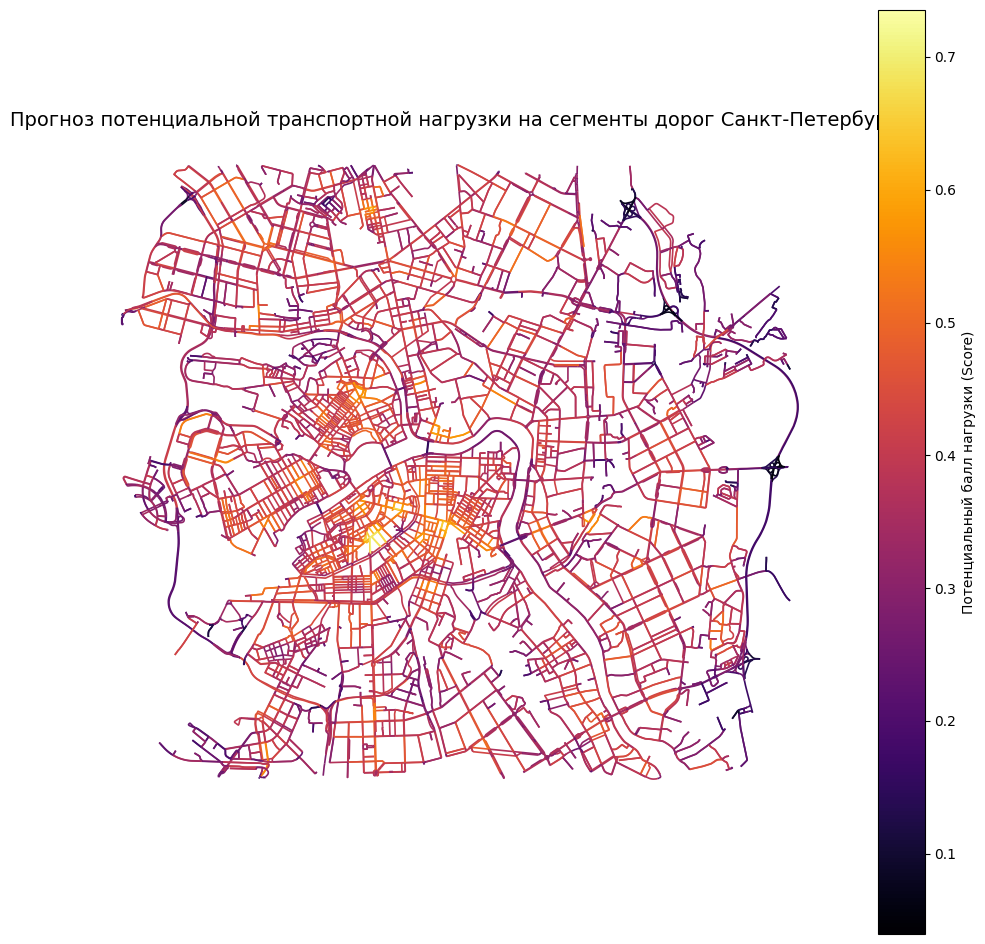

In [41]:
# Задание 15

# Делаем финальный прогноз настроенной моделью для абсолютно всех сегментов дорог
roads["predicted_traffic_load"] = tuned_model.predict(X)

# Возвращаем геометрию обратно в систему WGS84 для отрисовки карты
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=edges_m.crs).to_crs(4326)

# Отрисовка тепловой ГИС-карты
fig, ax = plt.subplots(figsize=(12, 12))
roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.2,
    legend=True,
    cmap="inferno",
    legend_kwds={'label': "Потенциальный балл нагрузки (Score)"}
)

ax.set_title("Прогноз потенциальной транспортной нагрузки на сегменты дорог Санкт-Петербурга", fontsize=14)
ax.set_axis_off()
plt.show()